In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
SAMPLE_RATE = 40.5  # Sample rate in Hz

In [51]:
def invert_signal(signal):
    signals = np.array(signal)
    mean_signal = signals.mean()
    inverted_signals = 2 * mean_signal - signals
    return inverted_signals

In [52]:
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks, medfilt

def bandpass_ppg(x, fs, low=0.5, high=8.0, order=3):
    """
    Bandpass for PPG morphology: keeps ~heart-rate band and removes drift/high noise.
    Tune low/high based on your data (fs=125 typical).
    """
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

# def remove_baseline_median(x, fs, win_sec=1.5):
#     k = int(win_sec * fs)
#     if k % 2 == 0: k += 1
#     base = medfilt(x, kernel_size=k)
#     return x - base

def detect_valleys_ppg(
    signal,
    fs=50.0,
    low=0.5,
    high=8.0,
    peak_min_dist_s=0.05,     # min distance between systolic peaks (sec)
    peak_prominence=None,     # if None, auto from robust stats
    valley_search_s=(0.15, 0.7)  # search window BEFORE peak for valley (sec)
    # baseline_win_s=1.5,
    # between_peaks_margin_s=0.08,
    # valley_mad_thresh=6.0
):
    """
    Returns:
      valleys: np.array of valley indices
      peaks: np.array of systolic peak indices
      filt: filtered signal used for detection
    """
    x = np.asarray(signal, dtype=np.float32)

    # if baseline_win_s is not None:
    #     x = remove_baseline_median(x, fs, win_sec=baseline_win_s)

    # 1) Filter
    xf = bandpass_ppg(x, fs=fs, low=low, high=high, order=3)

    # 2) Peak detection (systolic peaks)
    min_dist = int(peak_min_dist_s * fs)

    # Auto prominence: based on MAD (robust)
    if peak_prominence is None:
        med = np.median(xf)
        mad = np.median(np.abs(xf - med)) + 1e-8
        peak_prominence = 3.0 * mad  # adjust 2.0–4.0 depending on noise

    peaks, props = find_peaks(xf, distance=min_dist, prominence=peak_prominence)

    # 3) Valley detection: for each peak, search for minimum in a window before it
    vmin = int(valley_search_s[0] * fs)
    vmax = int(valley_search_s[1] * fs)

    valleys = []
    for p in peaks:
        left = max(0, p - vmax)
        right = max(0, p - vmin)
        if right <= left:
            continue
        seg = xf[left:right]
        # v_local = np.argmin(seg)
        # if seg[v_local] < -6 * mad:
        #   continue
        v = left + int(np.argmin(seg))
        valleys.append(v)

    valleys = np.array(valleys, dtype=int)

    # 4) Cleanup: ensure strictly increasing and unique
    if len(valleys) > 1:
        valleys = np.unique(valleys)

    return valleys, peaks, xf

In [53]:
from scipy.interpolate import CubicSpline

def spline_baseline_removal_v2(signal, valleys):    
    spline = CubicSpline(valleys, signal[valleys], bc_type="natural", extrapolate=False)
    baseline = np.full_like(signal, np.nan, dtype=np.float32)
    
    valid = (np.arange(len(signal)) >= valleys[0]) & \
            (np.arange(len(signal)) <= valleys[-1])

    baseline[valid] = spline(np.arange(len(signal))[valid])

    detrended = signal.copy()
    detrended[valid] -= baseline[valid]
    
    detrended = detrended[valleys[0]:valleys[-1]+1]
    
    segments = []
    for i in range(len(valleys) - 1):
        start = valleys[i]
        end = valleys[i + 1]
        segment = detrended[start - valleys[0]:end - valleys[0] + 1]
        segments.append(segment)
    
    return detrended, baseline, segments

In [54]:
ppgsignals = pd.read_csv('waveform_u1.csv')

In [55]:
ir_signals = invert_signal(ppgsignals["signal"])

In [56]:
ir_valleys, ir_peaks, ir_filt = detect_valleys_ppg(ir_signals, fs=SAMPLE_RATE, low=0.5, high=6.0)
ir_detrended, ir_baseline, ir_segments = spline_baseline_removal_v2(ir_filt, ir_valleys)

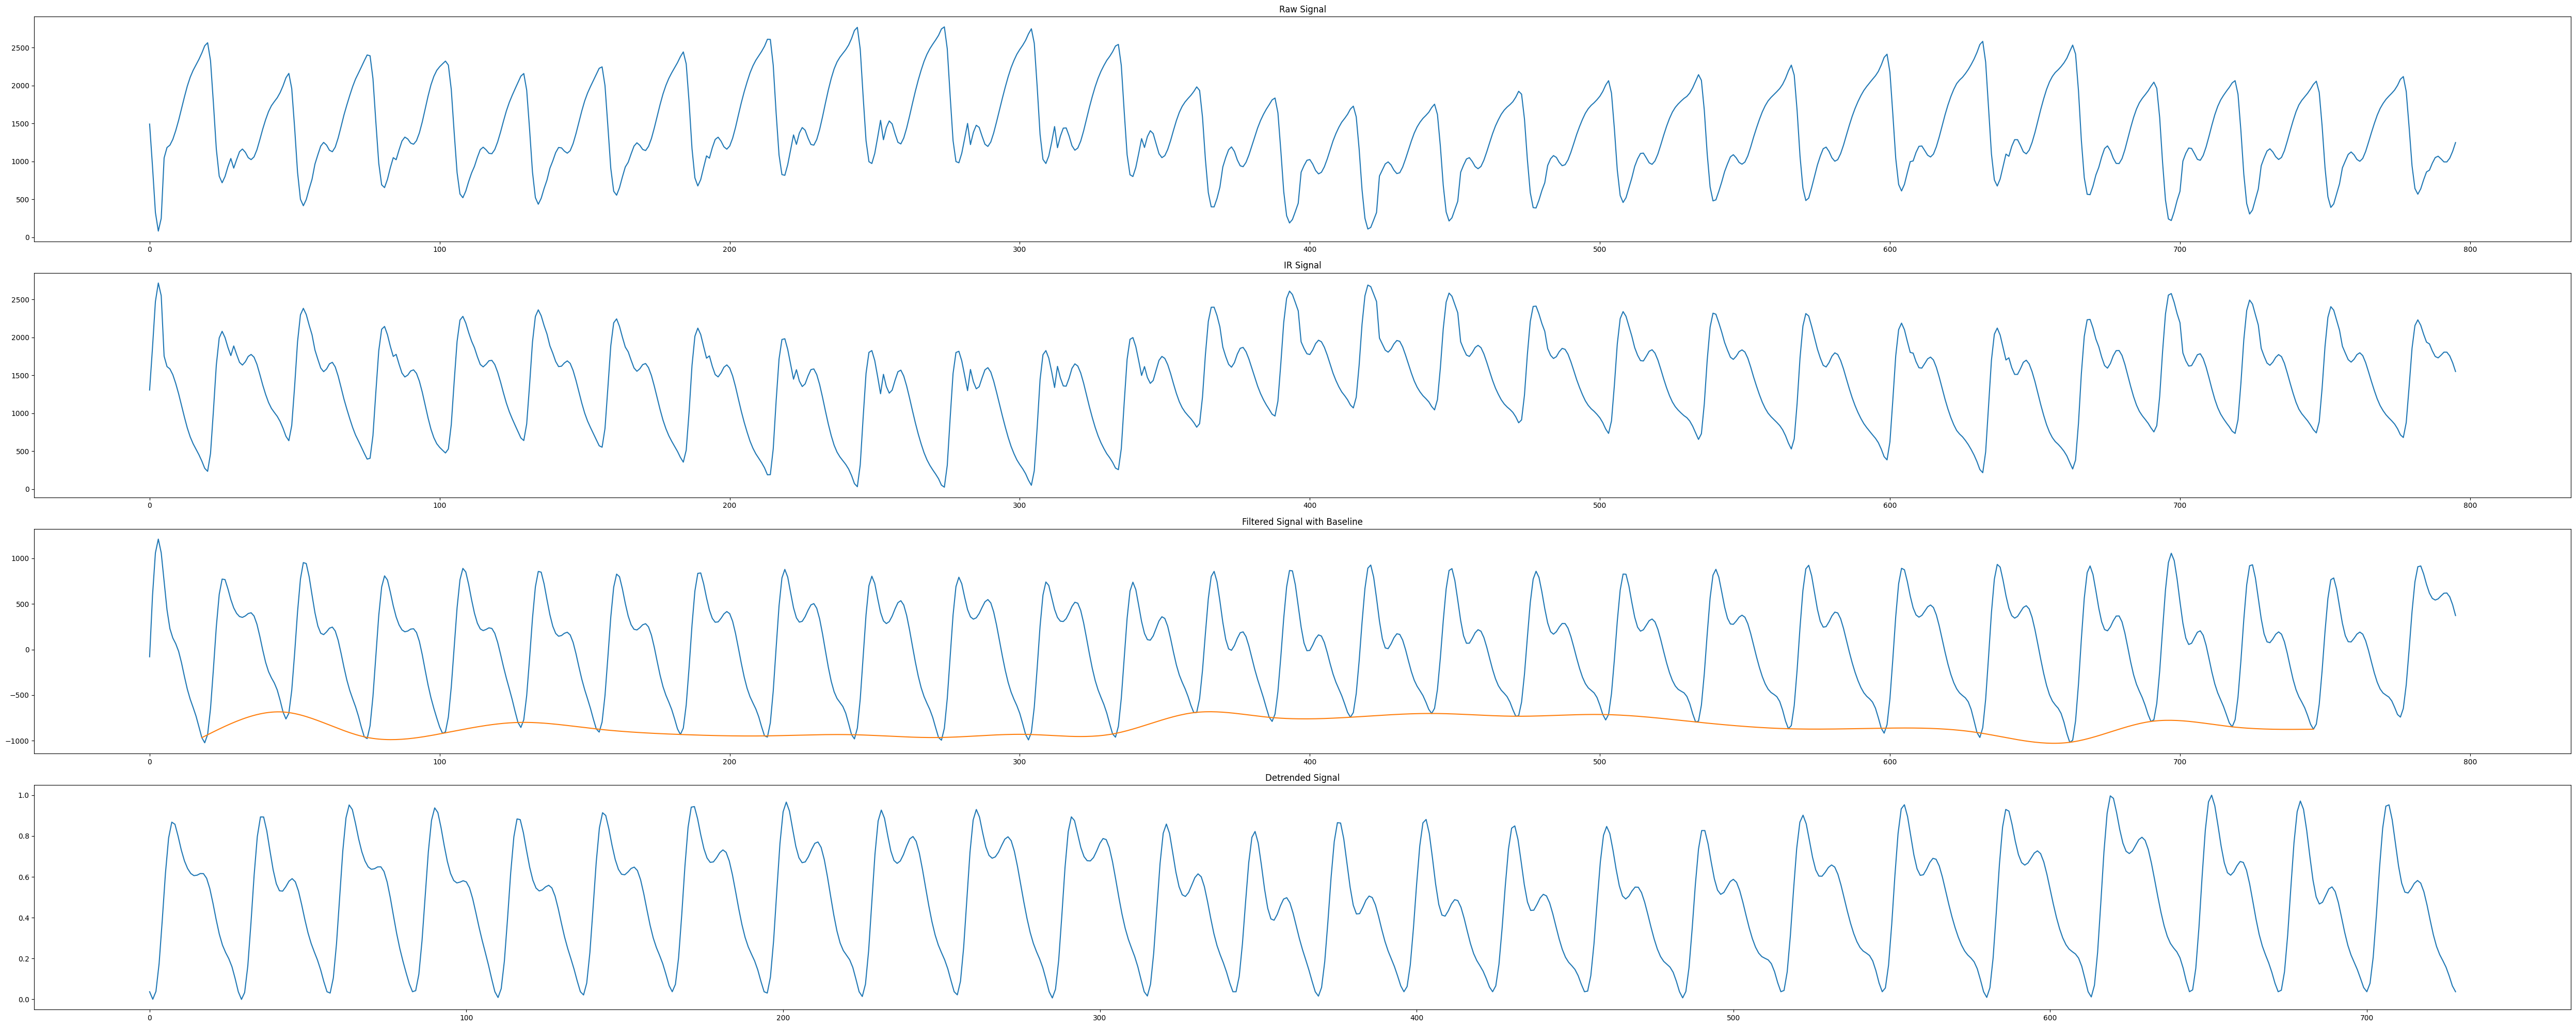

In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
fig, axes = plt.subplots(4, 1, figsize=(50, 20))

axes[0].plot(ppgsignals["signal"])
axes[0].set_title('Raw Signal')

axes[1].plot(ir_signals)
axes[1].set_title('IR Signal')

axes[2].plot(ir_filt)
axes[2].plot(ir_baseline)
axes[2].set_title('Filtered Signal with Baseline')

axes[3].plot(scaler.fit_transform(ir_detrended.reshape(-1, 1)))
axes[3].set_title('Detrended Signal')

plt.tight_layout()
plt.show()

